# Heart Attack Prediction Model 
This model is based on quantitative and qualitative data of the diffrent patients, from common measured health parameters like Blood Preasure, Cholerterol levels, Heart rate etc, to lifestyle choices such as Excercise rate, Alcohol consumption and so on.  

In [3]:
import numpy as nu
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [4]:
import os

folder = os.getcwd()

In [5]:
print(folder)

c:\Users\Data Analyst\Documents\GitHub\Machine_Learning_and_AI\Predictive_Heart_Attack_Model


In [6]:
Heart_Data =pd.read_csv ( f"{folder}\heart_attack_russia.csv" )
print(Heart_Data.info())
print(Heart_Data.head())
print(Heart_Data.shape)

<>:1: SyntaxWarning: invalid escape sequence '\h'
<>:1: SyntaxWarning: invalid escape sequence '\h'
C:\Users\Data Analyst\AppData\Local\Temp\ipykernel_3656\1601541033.py:1: SyntaxWarning: invalid escape sequence '\h'
  Heart_Data =pd.read_csv ( f"{folder}\heart_attack_russia.csv" )


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     50000 non-null  int64  
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  object 
 3   Region                 50000 non-null  object 
 4   Blood_Pressure         50000 non-null  float64
 5   Cholesterol            50000 non-null  float64
 6   BMI                    50000 non-null  float64
 7   Heart_Rate             50000 non-null  int64  
 8   Exercise_Level         50000 non-null  object 
 9   Smoking                50000 non-null  bool   
 10  Alcohol_Consumption    24976 non-null  object 
 11  Diabetes               50000 non-null  bool   
 12  Family_History         50000 non-null  bool   
 13  Stress_Level           50000 non-null  int64  
 14  Heart_Attack           50000 non-null  bool   
 15  An

In [7]:
# Clean Data by filling in missing values with 0
Heart_Data = Heart_Data.fillna("None")

print(Heart_Data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     50000 non-null  int64  
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  object 
 3   Region                 50000 non-null  object 
 4   Blood_Pressure         50000 non-null  float64
 5   Cholesterol            50000 non-null  float64
 6   BMI                    50000 non-null  float64
 7   Heart_Rate             50000 non-null  int64  
 8   Exercise_Level         50000 non-null  object 
 9   Smoking                50000 non-null  bool   
 10  Alcohol_Consumption    50000 non-null  object 
 11  Diabetes               50000 non-null  bool   
 12  Family_History         50000 non-null  bool   
 13  Stress_Level           50000 non-null  int64  
 14  Heart_Attack           50000 non-null  bool   
 15  An

In [8]:
print("Integer and Float Columns:", Heart_Data.select_dtypes(include=['int64', 'float64']).columns)
print("Boolean Columns:", Heart_Data.select_dtypes(include=['bool']).columns)
print("String Columns:", Heart_Data.select_dtypes(include=['object']).columns)

Integer and Float Columns: Index(['ID', 'Age', 'Blood_Pressure', 'Cholesterol', 'BMI', 'Heart_Rate',
       'Stress_Level', 'Sleep_Hours', 'Health_Awareness', 'Daily_Water_Intake',
       'Mental_Health'],
      dtype='object')
Boolean Columns: Index(['Smoking', 'Diabetes', 'Family_History', 'Heart_Attack', 'Angina',
       'Heart_Disease_History', 'Medication', 'Obesity'],
      dtype='object')
String Columns: Index(['Gender', 'Region', 'Exercise_Level', 'Alcohol_Consumption', 'Diet',
       'Occupation', 'Income_Level', 'Physical_Activity', 'Education_Level',
       'Marital_Status', 'Urban_Rural'],
      dtype='object')


In [9]:
integer_columns = Heart_Data[['ID', 'Age', 'Blood_Pressure', 'Cholesterol', 'BMI', 'Heart_Rate',
       'Stress_Level', 'Sleep_Hours', 'Health_Awareness', 'Daily_Water_Intake',
       'Mental_Health']]

integer_columns = pd.DataFrame(integer_columns)
integer_columns.head()

,ID,Age,Blood_Pressure,Cholesterol,BMI,Heart_Rate,Stress_Level,Sleep_Hours,Health_Awareness,Daily_Water_Intake,Mental_Health
0,1,50,110.0,196.5,15.9,76,8,9.4,5,2.3,5
1,2,40,138.8,157.5,27.1,82,5,5.5,1,5.0,4
2,3,26,116.0,210.1,27.2,71,8,8.8,4,2.4,8
3,4,54,133.5,170.5,26.0,74,5,8.2,2,2.7,6
4,5,19,108.0,224.5,27.5,67,1,5.9,4,3.5,4


In [10]:
boolean_columns = Heart_Data[['Smoking', 'Diabetes', 'Family_History', 'Heart_Attack', 'Angina',
       'Heart_Disease_History', 'Medication', 'Obesity']]

boolean_columns.head()
boolean_columns = pd.DataFrame(boolean_columns)
boolean_columns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Smoking                50000 non-null  bool 
 1   Diabetes               50000 non-null  bool 
 2   Family_History         50000 non-null  bool 
 3   Heart_Attack           50000 non-null  bool 
 4   Angina                 50000 non-null  bool 
 5   Heart_Disease_History  50000 non-null  bool 
 6   Medication             50000 non-null  bool 
 7   Obesity                50000 non-null  bool 
dtypes: bool(8)
memory usage: 390.8 KB


In [11]:
string_columns = Heart_Data[['Gender', 'Region', 'Exercise_Level', 'Alcohol_Consumption', 'Diet',
       'Occupation', 'Income_Level', 'Physical_Activity', 'Education_Level',
       'Marital_Status', 'Urban_Rural']]

string_columns = pd.DataFrame(string_columns)
string_columns.head()

,Gender,Region,Exercise_Level,Alcohol_Consumption,Diet,Occupation,Income_Level,Physical_Activity,Education_Level,Marital_Status,Urban_Rural
0,Male,Rural,High,Moderate,Unhealthy,Unemployed,Low,Low,Primary,Married,Rural
1,Female,Urban,Moderate,None,Unhealthy,Employed,Low,Moderate,Higher,Married,Urban
2,Male,Rural,Moderate,Moderate,Unhealthy,Employed,Middle,High,Primary,Married,Urban
3,Female,Rural,Moderate,Moderate,Healthy,Student,Middle,Moderate,Higher,Married,Urban
4,Female,Urban,Low,None,Unhealthy,Employed,Middle,Low,Higher,Widowed,Urban


In [12]:
for column in string_columns:
    Encode = LabelEncoder()
    Heart_Data[column] = Encode.fit_transform(Heart_Data[column])
    print(f"{column} unique values after encoding:", Heart_Data[column].unique())

Gender unique values after encoding: [1 0 2]
Region unique values after encoding: [0 2 1]
Exercise_Level unique values after encoding: [0 2 1]
Alcohol_Consumption unique values after encoding: [1 2 0]
Diet unique values after encoding: [2 0 1]
Occupation unique values after encoding: [3 0 2 1]
Income_Level unique values after encoding: [1 2 0]
Physical_Activity unique values after encoding: [1 2 0]
Education_Level unique values after encoding: [1 0 2]
Marital_Status unique values after encoding: [1 3 2 0]
Urban_Rural unique values after encoding: [0 1]


In [13]:
Heart_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     50000 non-null  int64  
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  int64  
 3   Region                 50000 non-null  int64  
 4   Blood_Pressure         50000 non-null  float64
 5   Cholesterol            50000 non-null  float64
 6   BMI                    50000 non-null  float64
 7   Heart_Rate             50000 non-null  int64  
 8   Exercise_Level         50000 non-null  int64  
 9   Smoking                50000 non-null  bool   
 10  Alcohol_Consumption    50000 non-null  int64  
 11  Diabetes               50000 non-null  bool   
 12  Family_History         50000 non-null  bool   
 13  Stress_Level           50000 non-null  int64  
 14  Heart_Attack           50000 non-null  bool   
 15  An

In [14]:
for column in boolean_columns:
        Heart_Data[column] = Heart_Data[column].astype(int)
        print(f"{column} values after conversion:", Heart_Data[column].unique())

Smoking values after conversion: [0 1]
Diabetes values after conversion: [0 1]
Family_History values after conversion: [0 1]
Heart_Attack values after conversion: [0 1]
Angina values after conversion: [0 1]
Heart_Disease_History values after conversion: [0 1]
Medication values after conversion: [0 1]
Obesity values after conversion: [0 1]


In [15]:
Heart_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     50000 non-null  int64  
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  int64  
 3   Region                 50000 non-null  int64  
 4   Blood_Pressure         50000 non-null  float64
 5   Cholesterol            50000 non-null  float64
 6   BMI                    50000 non-null  float64
 7   Heart_Rate             50000 non-null  int64  
 8   Exercise_Level         50000 non-null  int64  
 9   Smoking                50000 non-null  int64  
 10  Alcohol_Consumption    50000 non-null  int64  
 11  Diabetes               50000 non-null  int64  
 12  Family_History         50000 non-null  int64  
 13  Stress_Level           50000 non-null  int64  
 14  Heart_Attack           50000 non-null  int64  
 15  An

In [40]:
Heart_Data['Heart_Attack'].value_counts()

Heart_Attack
0    44119
1     5881
Name: count, dtype: int64

Data Skewed toward 0 value
balance it out

In [16]:
X = Heart_Data.drop(['Heart_Attack'], axis=1)

Y = Heart_Data["Heart_Attack"]

In [17]:
X.shape

(50000, 29)

In [18]:
Y.shape

(50000,)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [20]:
Scaler = StandardScaler()
X_train = Scaler.fit_transform(X_train)
X_test = Scaler.transform(X_test)

In [21]:
y_train.shape

(40000,)

In [34]:
kn = KNeighborsRegressor()
kn.fit(X_train,y_train)
pre_1=kn.predict(X_test)
print( f"Accuracy Score = {accuracy_score(y_test, pre_1.round())}")
print("Classification Report:")
print(classification_report(y_test, pre_1.round()))
stat_1 = classification_report(y_test, pre_1.round(), output_dict= True)

Accuracy Score = 0.8744
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.99      0.93      8854
           1       0.12      0.02      0.03      1146

    accuracy                           0.87     10000
   macro avg       0.50      0.50      0.48     10000
weighted avg       0.80      0.87      0.83     10000



In [23]:
stat_1 = pd.DataFrame(stat_1).transpose()

In [ ]:
lr=LinearRegression()
lr.fit(X_train,y_train)
pre_2 = lr.predict(X_test)
print( f"Accuracy Score = {accuracy_score(y_test, pre_2.round())}")
print("Classification Report:")
print(classification_report(y_test, pre_2.round()))
stat_2 = classification_report(y_test, pre_2.round(), output_dict= True)

Accuracy Score = 0.8854


C:\Users\Data Analyst\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Data Analyst\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Data Analyst\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

              precision    recall  f1-score   support

           0       0.89      1.00      0.94      8854
           1       0.00      0.00      0.00      1146

    accuracy                           0.89     10000
   macro avg       0.44      0.50      0.47     10000
weighted avg       0.78      0.89      0.83     10000



C:\Users\Data Analyst\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Data Analyst\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


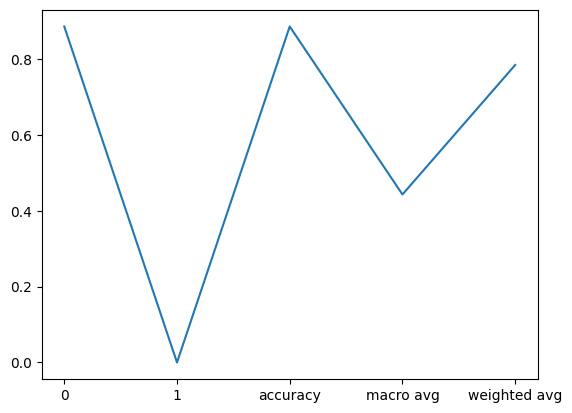

In [39]:
stat_2 = pd.DataFrame(stat_2).transpose()

plt.plot(stat_2['precision'])
plt.show()